# Collaborative Filtering – Homi Shop ML Service

Notebook này kiểm thử và giải thích chi tiết phương pháp **Collaborative Filtering (Lọc cộng tác)** được triển khai trong hệ thống tại `ml_service/app/services/recommendation_service.py`.

## Tổng quan thuật toán
Trái ngược với Content-based (dựa trên phân tích đặc điểm cấu tạo của hàng hoá), Collaborative Filtering (CF) dựa hoàn toàn vào **hành vi của đám đông**. CF bỏ qua đặc tính vật lý của sản phẩm mà chỉ theo dõi hành vi tương tác.

### Nguyên lý cơ bản:
> *"Nếu A và B có cùng chung lịch sử mua sắm một vài vật dụng, xác suất cao là A sẽ thích những món đồ khác mà B đã mua."*

### Quy trình tổng quát trải dọc 4 bước:
| Bước | Phase | Ý nghĩa kỹ thuật |
|------|-----|-------|
| **1** | **Build Matrix** | Thiết lập ma trận User-Item từ lịch sử Interactions |
| **2** | **User Similarity** | Tính toán khoảng cách (Cosine Similarity) giữa các Users |
| **3** | **Weighted Prediction** | Dự đoán điểm số kỳ vọng ở những SP user chưa từng mua |
| **4** | **Fallback** | Trả về gợi ý có độ chính xác cao nhất. Nếu user mới, tự động rơi vào Fallback. |

## 1. Thiết lập môi trường và cấu hình thư viện

Để thực hiện các phân tích này, nhóm sử dụng các công cụ phổ biến trong khoa học dữ liệu:
- **Pandas & Numpy**: Xử lý dữ liệu dạng bảng và ma trận số một cách hiệu quả.
- **Scikit-learn**: Cung cấp bộ công cụ `TfidfVectorizer` để biến đổi chuỗi thành vector và hàm `cosine_similarity` để tính toán độ tương đồng.
- **Matplotlib & Seaborn**: Vẽ biểu đồ và heat map trực quan.

> **Lưu ý**: Chạy cell này trước tiên để setup Pandas, Numpy, Scikit-learn và các công cụ hiển thị.

In [3]:
import sys, subprocess
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn', '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('Thư viện đã sẵn sàng')

Thư viện đã sẵn sàng


## 2. Nạp dữ liệu mô phỏng từ database

Dữ liệu được trích xuất từ database PostgreSQL của Homi Shop (đưới dạng file CSV) bao gồm các bảng chính luôn liên kết chặt chẽ với nhau:
1. **Sản phẩm (Products)**: Chứa toàn bộ thông tin chi tiết về sản phẩm (tên, giá, đặc tính).
2. **Đánh giá (Reviews) & Đơn hàng (Orders)**: Ghi nhận hành vi mua sắm và đánh giá của khách hàng.

In [4]:
# Đọc dữ liệu từ các file CSV được export từ database
reviews_raw  = pd.read_csv('furniture_shop.reviews.csv')
orders_raw   = pd.read_csv('furniture_shop.orders.csv')
products_raw = pd.read_csv('furniture_shop.products.csv')

# Map product_id -> name (dùng xuyên suốt notebook)
product_names = dict(zip(products_raw['_id'].astype(str), products_raw['name']))

print(f'Reviews : {len(reviews_raw)}')
print(f'Orders  : {len(orders_raw)}')
print(f'Products: {len(products_raw)}')

print('\n--- 5 bản ghi đầu tiên của mỗi bảng ---')
print('Sản phẩm:')
display(products_raw.head())
print('Đánh giá:')
display(reviews_raw.head())
print('Đơn hàng:')
display(orders_raw.head())

Reviews : 46
Orders  : 64
Products: 13

--- 5 bản ghi đầu tiên của mỗi bảng ---
Sản phẩm:


,_id,name,sku,description,price,category,brand,stock,images[0],images[1],images[2],images[3],images[4],images[5],images[6],model3DUrl,dimensions.width,dimensions.height,dimensions.length,colors[0],colors[1],colors[2],materials[0],materials[1],materials[2],tags[0],tags[1],tags[2],averageRating,totalReviews,soldCount,createdAt,updatedAt,slug,isDeleted,__v,isFeatured
0,6933adafb53918b85561127a,Sofa Góc Lullaby,SF001,"Sofa góc Lullaby thiết kế hiện đại, bọc vải nỉ...",15000000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,9,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,160,85,200,Be sáng,Kem,NaN,Vải nỉ,NaN,NaN,sofa,hiện đại,phòng khách,2.5,2,40,2025-12-06T04:14:39.727Z,2026-04-05T03:51:45.179Z,sofa-goc-lullaby,False,0,False
1,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,SF002,"Sofa băng 3 chỗ ngồi bọc da bò Ý nhập khẩu, ch...",28500000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,0,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/up...,90,90,220,Nâu bò,Đen,NaN,Da thật,Thép,NaN,Sofa,Da thật,Sang trọng,3.0,2,41,2025-12-06T05:50:24.767Z,2026-04-05T03:51:45.179Z,sofa-bang-da-bo-that,False,0,False
2,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,SF003,"Sofa có thể mở ra thành giường ngủ, giải pháp ...",8500000,693296dbba0c79a52537afd1,69329ddf63a83d44a1f5207c,12,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,https://res.cloudinary.com/drgho551x/image/upl...,85,80,180,Xanh Navy,NaN,NaN,Vải bố,Khung gỗ,NaN,Sofa bed,Thông minh,Nhỏ gọn,3.0,3,43,2025-12-06T06:01:03.379Z,2026-04-05T03:51:45.179Z,sofa-giuong-thong-minh,False,0,NaN
3,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,SF004,"Ghế sofa đơn kèm đôn gác chân, thiết kế ôm sát...",4200000,693296dbba0c79a52537afd1,69329f50e26db821bb576aa3,18,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,80,100,Be,Kem,Nâu,Nhung,Da thật,Gỗ,Sofa,Thư giãn,Đọc sách,4.0,1,55,2025-12-06T06:28:42.053Z,2026-04-05T03:51:45.179Z,sofa-don-thu-gian,False,0,True
4,6933cfb22ea2861093a39b5b,Bàn Trà Kính Tròn,BT001,"Bàn trà mặt kính cường lực, chân gỗ sang trọng.",2500000,693296f6ba0c79a52537afd9,69329f0de26db821bb576a9c,26,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,https://res.cloudinary.com/drgho551x/image/upl...,NaN,NaN,NaN,NaN,https://res.cloudinary.com/drgho551x/image/upl...,80,40,80,Vàng,Nâu,NaN,Kính cường lực,Gỗ,NaN,Bàn trà,Hiện đại,Kính,5.0,1,47,2025-12-06T06:39:46.473Z,2026-04-05T03:51:45.179Z,ban-tra-kinh-tron,False,2,True


Đánh giá:


,_id,product,user,rating,comment,createdAt,updatedAt,__v
0,22fb3331d2d37e4554dff67c,6933c4202ea2861093a39b34,b147c5a48776c6549027856c,5,"rat tot, yeu thich mau sac va do ben",2025-12-07T08:11:00Z,2025-12-07T08:11:00Z,0
1,1be3094c137ea70682b7ced8,6933c69f2ea2861093a39b3d,b147c5a48776c6549027856c,4,"good quality, hai long, worth the money",2025-12-18T07:46:00Z,2025-12-18T07:46:00Z,0
2,982758f693541b2894409746,6933d83cf17e1b6d5ec15b0b,b147c5a48776c6549027856c,3,o muc chap nhan duoc cho tam gia,2025-12-07T17:22:00Z,2025-12-07T17:22:00Z,0
3,7656563c180802f863cf0636,6933adafb53918b85561127a,b147c5a48776c6549027856c,4,"great product, recommend for family use",2026-04-05T01:57:00Z,2026-04-05T01:57:00Z,0
4,73bece9989e05fd4355a3b07,6933cfb22ea2861093a39b5b,50d83bf3615543cb3a606532,4,"good quality, hai long, worth the money",2026-02-14T04:16:00Z,2026-02-14T04:16:00Z,0


Đơn hàng:


,_id,user,code,items[0].product,items[0].name,items[0].quantity,items[0].price,items[0].image,items[0]._id,items[1].product,items[1].name,items[1].quantity,items[1].price,items[1].image,items[1]._id,items[2].product,items[2].name,items[2].quantity,items[2].price,items[2].image,items[2]._id,shippingAddress.fullName,shippingAddress.phone,shippingAddress.province,shippingAddress.district,shippingAddress.ward,shippingAddress.address,payment.method,payment.status,payment.transactionId,status,subTotal,shippingFee,discount.code,discount.amount,totalAmount,notes,createdAt,updatedAt,__v
0,8a8ccaf002abb07b531a9d72,b147c5a48776c6549027856c,ORD261001,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,2,8900000,https://res.cloudinary.com/drgho551x/image/upl...,a74bf5b9374a3fd70410d71d,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,d91c182cbc0772cdff8b72bb,6933c69f2ea2861093a39b3d,Sofa Giường Thông Minh,3.0,8500000.0,https://res.cloudinary.com/drgho551x/image/upl...,94e70ecd02a83d45405604c9,Nguyen Minh,999475954,Da Nang,Cau Giay,Thach Thang,622 Nguyen Van Linh,BANK,pending,TX160155081585,processing,73300000,0,FLASH20,0,73300000,Seed dataset for recommendation and analytics,2026-01-19T19:14:00Z,2026-01-19T19:14:00Z,0
1,95844b6b2d8ce234d67e8fb0,b147c5a48776c6549027856c,ORD261002,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,1,8900000,https://res.cloudinary.com/drgho551x/image/upl...,072f1b71139594bcee04a773,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,b2fd568f00e6f9af62ef9575,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,912561677,Can Tho,Hai Chau,An Hoa,773 Nguyen Van Linh,BANK,completed,TX206683887955,delivered,65900000,45000,WELCOME10,100000,65845000,Seed dataset for recommendation and analytics,2026-01-01T03:05:00Z,2026-01-01T03:05:00Z,0
2,2f719f554d2dcac3fcf750b8,b147c5a48776c6549027856c,ORD261003,6933adafb53918b85561127a,Sofa Góc Lullaby,3,15000000,https://res.cloudinary.com/drgho551x/image/upl...,ddd1669b24417f755b132524,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nguyen Minh,992701085,Ho Chi Minh,Quan 1,Dich Vong,992 Nguyen Van Linh,COD,pending,NaN,processing,45000000,0,WELCOME10,250000,44750000,Seed dataset for recommendation and analytics,2025-12-08T13:58:00Z,2025-12-08T13:58:00Z,0
3,d85ff734b88de3690a8e8335,b147c5a48776c6549027856c,ORD261004,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,3,8900000,https://res.cloudinary.com/drgho551x/image/upl...,0868533749af3c0487a79df5,6933adafb53918b85561127a,Sofa Góc Lullaby,2.0,15000000.0,https://res.cloudinary.com/drgho551x/image/upl...,249159cd47dfbd2566fbd195,6933c4202ea2861093a39b34,Sofa Băng Da Bò Thật,2.0,28500000.0,https://res.cloudinary.com/drgho551x/image/upl...,ea6ea560994dd2465894d7f3,Nguyen Minh,959813731,Da Nang,Quan 1,Thach Thang,716 Nguyen Van Linh,COD,completed,NaN,delivered,113700000,45000,VIP50,100000,113645000,Seed dataset for recommendation and analytics,2026-01-02T20:58:00Z,2026-01-02T20:58:00Z,0
4,88af292d03dec8f70f820a7f,50d83bf3615543cb3a606532,ORD261005,6933cd1a2ea2861093a39b50,Sofa Đơn Thư Giãn,2,4200000,https://res.cloudinary.com/drgho551x/image/upl...,174b7454fa0da64f0c7201cb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tran Lan,940960299,Da Nang,Cau Giay,Thach Thang,555 Nguyen Van Linh,BANK,completed,TX442660673649,delivered,8400000,45000,WELCOME10,100000,8345000,Seed dataset for recommendation and analytics,2025-11-19T10:25:00Z,2025-11-19T10:25:00Z,0


## 3. Tiền xử lý dữ liệu và xây dựng ma trận User-Item
Xử lý dữ liệu thô để tạo ra ma trận User-Item, trong đó mỗi hàng đại diện cho một người dùng và mỗi cột đại diện cho một sản phẩm. Giá trị trong ma trận là điểm số thể hiện mức độ quan tâm của người dùng đối với sản phẩm đó.
Trong đó, điểm số được tính dựa trên cả đánh giá (rating) và số lượng sản phẩm đã đặt hàng (quantity), với công thức trọng số như sau:

**Công thức trọng số (Weighted Score Computation):**
```python
score(user, product) = Σ(rating) + Σ(quantity × 1.5)
```
Thuật toán chủ động cấp hệ số **×1.5** đối với hành động "Add Item To Order" vì nó chứng tỏ quyết định đầu tư mạnh mẽ hơn nhiều so với việc chỉ thả sao đánh giá.

   Bảng tương tác: (62, 3)
   Số users   : 12
   Số products: 13


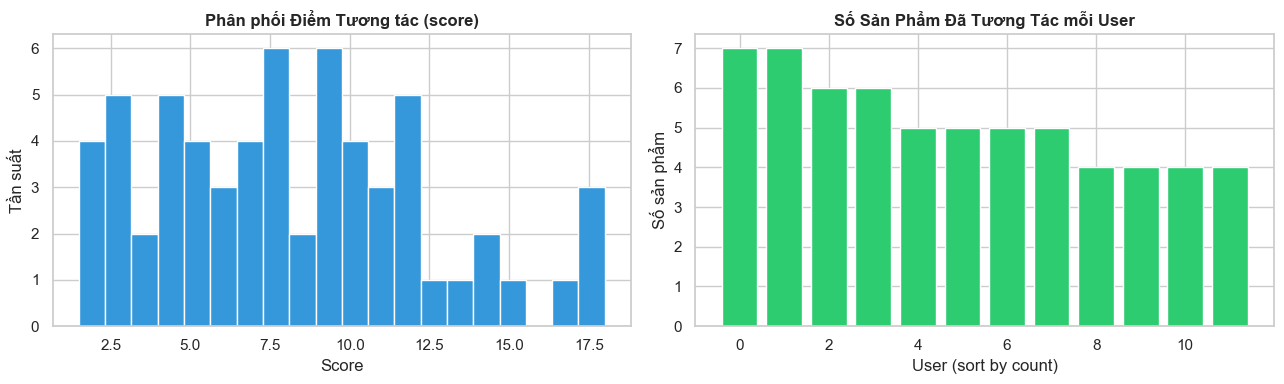

,user_id,product_id,score
0,b147c5a48776c6549027856c,6933c4202ea2861093a39b34,11.0
1,b147c5a48776c6549027856c,6933c69f2ea2861093a39b3d,8.5
2,b147c5a48776c6549027856c,6933d83cf17e1b6d5ec15b0b,12.0
3,b147c5a48776c6549027856c,6933adafb53918b85561127a,14.5
4,50d83bf3615543cb3a606532,6933cfb22ea2861093a39b5b,7.0
5,50d83bf3615543cb3a606532,6948c80e82c30577b2147244,5.0
6,50d83bf3615543cb3a606532,6933d83cf17e1b6d5ec15b0b,17.5
7,bdad327b5746c2f632e0f109,6933c4202ea2861093a39b34,2.5


In [6]:
def build_interactions_df(reviews_raw, orders_raw):
    """Tái hiện interactions_to_df() từ data_prep_service.py"""
    signals = defaultdict(float)

    # Từ reviews: score += rating
    for _, r in reviews_raw.iterrows():
        uid = str(r['user'])
        pid = str(r['product'])
        if uid and pid:
            signals[(uid, pid)] += float(r.get('rating', 0) or 0)

    # Từ orders: score += quantity * 1.5
    item_p_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.product')]
    item_q_cols = [c for c in orders_raw.columns if c.startswith('items[') and c.endswith('.quantity')]

    for _, o in orders_raw.iterrows():
        uid = str(o['user'])
        for pc, qc in zip(item_p_cols, item_q_cols):
            pid = o.get(pc)
            qty = o.get(qc)
            if pd.notna(pid) and pd.notna(qty):
                signals[(uid, str(pid))] += float(qty) * 1.5

    rows = [{'user_id': u, 'product_id': p, 'score': s}
            for (u, p), s in signals.items()]
    return pd.DataFrame(rows)


interactions = build_interactions_df(reviews_raw, orders_raw)
print(f'   Bảng tương tác: {interactions.shape}')
print(f'   Số users   : {interactions["user_id"].nunique()}')
print(f'   Số products: {interactions["product_id"].nunique()}')

# --- Visualise phân phối ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

interactions['score'].hist(bins=20, ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Phân phối Điểm Tương tác (score)', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Tần suất')

user_counts = interactions.groupby('user_id').size().sort_values(ascending=False)
axes[1].bar(range(len(user_counts)), user_counts.values, color='#2ecc71', edgecolor='white')
axes[1].set_title('Số Sản Phẩm Đã Tương Tác mỗi User', fontweight='bold')
axes[1].set_xlabel('User (sort by count)')
axes[1].set_ylabel('Số sản phẩm')

plt.tight_layout()
plt.show()
interactions.head(8)

## 4. Xây dựng Pivot Table

Với số lượng hàng hóa và người dùng rất lớn, nhóm đã cấu trúc lại hệ thống số liệu thành một ma trận 2 chiều (Pivot Table), ở đó:
- **Hàng (Row)**: Là các ID người dùng.
- **Cột (Col)**: Là các ID sản phẩm.
- **Giá trị (Value)**: Điểm Interaction (Nếu chưa biết, mặc định khởi tạo = 0).

Ma trận này thường rơi vào trạng thái *Thưa (Sparse)* vì mỗi account chỉ thường mua sắm một vài món đồ cụ thể trong catalog hàng ngàn sản phẩm.

    User-Item Matrix: (12, 13)
   12 users × 13 products
   Sparsity: 60.3% (giá trị = 0)


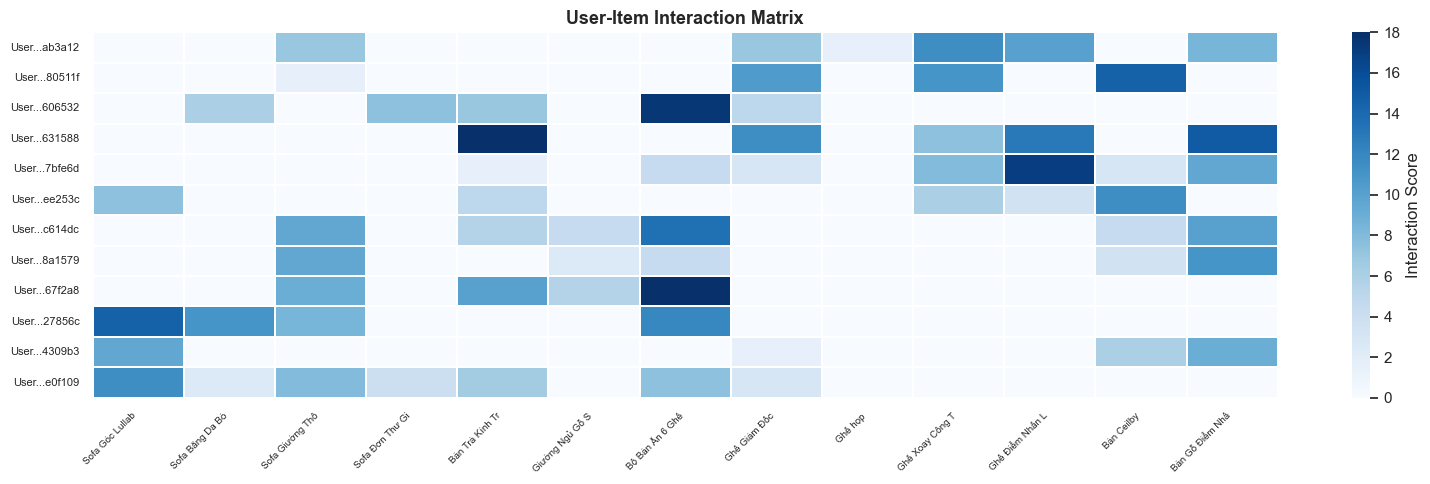

In [ ]:
matrix = interactions.pivot_table(
    index      = 'user_id',
    columns    = 'product_id',
    values     = 'score',
    fill_value = 0
)

print(f'    User-Item Matrix: {matrix.shape}')
print(f'   {matrix.shape[0]} users × {matrix.shape[1]} products')
print(f'   Sparsity: {(matrix == 0).sum().sum() / matrix.size * 100:.1f}% (giá trị = 0)')

# Visualise heatmap
matrix_display = matrix.copy()
matrix_display.columns = [product_names.get(str(c), str(c))[:15] for c in matrix_display.columns]
matrix_display.index   = [f'User...{str(i)[-6:]}' for i in matrix_display.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(matrix_display, cmap='Blues', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Interaction Score'})
ax.set_title('User-Item Interaction Matrix', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

## 5. Hệ số tương quan User-User (Cosine Similarity)
 Xác định mức độ giống nhau về hành vi giữa **User U** và **User V** bằng Cosine Similarity trên từng hàng của Ma Trận (giống cách làm ở Content-based nhưng đối tượng thay đổi).

$$\text{sim}(u, v) = \frac{\vec{u} \cdot \vec{v}}{\|\vec{u}\|\|\vec{v}\|}$$

Tập giá trị đầu ra chạy từ `0.0` (Trái ngược) đến `1.0` (Hành vi hoàn toàn trùng khớp).

    User Similarity Matrix: (12, 12)


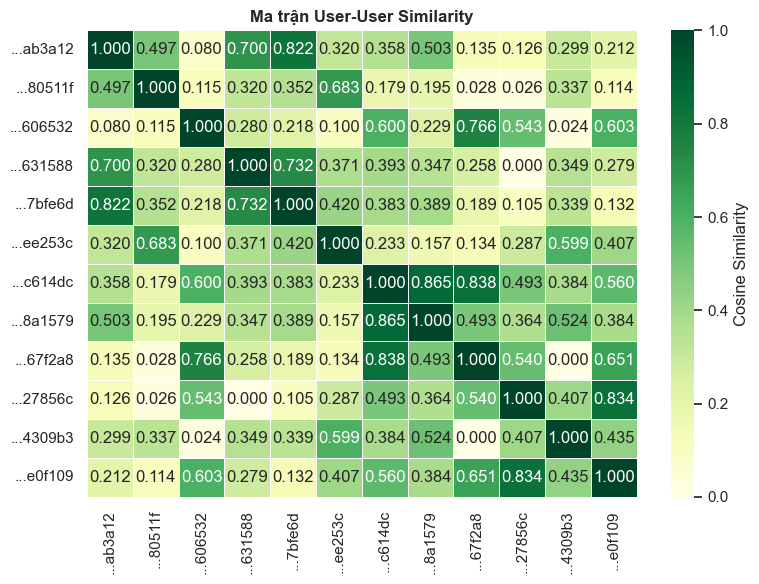

In [8]:
user_sim = cosine_similarity(matrix)
sim_df   = pd.DataFrame(user_sim, index=matrix.index, columns=matrix.index)

print(f'    User Similarity Matrix: {sim_df.shape}')

# Rút gọn index để hiển thị
display_index       = [f'...{str(i)[-6:]}' for i in sim_df.index]
sim_display         = sim_df.copy()
sim_display.index   = display_index
sim_display.columns = display_index

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(sim_display, annot=True, fmt='.3f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Ma trận User-User Similarity', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Dự đoán điểm số (Weighted Average Prediction)

Collaborative Filtering xảy ra khi cố gắng ước đoán *"Liệu user này sẽ cho mấy điểm sản phẩm kia nếu họ trải nghiệm?"* bằng cách xem xét thái độ của những người GIỐNG HỌ NHẤT với sản phẩm đó.

**Toán học hóa quá trình:**
$$\hat{r}(u, p) = \frac{\sum_{v \neq u} \text{sim}(u,v) \cdot r(v,p)}{\sum_{v \neq u} |\text{sim}(u,v)|}$$

Kết quả dự đoán trả về được làm tròn và sử dụng làm cơ sở để xếp hạng.

In [ ]:
def collaborative_recommend(target_user_id: str, top_k: int = 5):
    """
    Tái hiện collaborative_recommendation() từ recommendation_service.py

    Công thức dự đoán:
        pred(u, p) = Σ_v [sim(u,v) * rating(v,p)] / Σ_v |sim(u,v)|
    """
    if target_user_id not in matrix.index:
        print(f'User không tồn tại trong matrix → fallback')
        product_scores = interactions.groupby('product_id')['score'].sum().sort_values(ascending=False)
        return [{'product_id': pid, 'name': product_names.get(str(pid), ''), 'score': float(s)}
                for pid, s in product_scores.head(top_k).items()]

    # Lấy weights = similarity của target user với tất cả users khác
    weights = sim_df.loc[target_user_id].drop(target_user_id)

    if weights.abs().sum() == 0:
        print('Weights rỗng (user không có điểm tương đồng) → fallback')
        product_scores = interactions.groupby('product_id')['score'].sum().sort_values(ascending=False)
        return [{'product_id': pid, 'name': product_names.get(str(pid), ''), 'score': float(s)}
                for pid, s in product_scores.head(top_k).items()]

    # Weighted average rating
    weighted = np.dot(weights.values, matrix.loc[weights.index].values)
    pred     = weighted / (np.abs(weights.values).sum() + 1e-8)

    # Loại sản phẩm user đã mua/đánh giá
    target_seen = set(matrix.columns[matrix.loc[target_user_id] > 0])
    ranked_idx  = np.argsort(pred)[::-1]
    columns     = matrix.columns.tolist()

    results = []
    for idx in ranked_idx:
        pid = columns[idx]
        if pid in target_seen:
            continue
        results.append({
            'product_id': pid,
            'name'      : product_names.get(str(pid), str(pid)[:12]),
            'score'     : round(float(pred[idx]), 4)
        })
        if len(results) >= top_k:
            break
    return results


# Test với user đầu tiên
target_user = matrix.index[0]
print(f'Đề xuất Collaborative Filtering cho user với ID: {str(target_user)}')
print(f'Sản phẩm user đã tương tác: {(matrix.loc[target_user] > 0).sum()} sản phẩm\n')

recs    = collaborative_recommend(target_user, top_k=5)
recs_df = pd.DataFrame(recs)
recs_df

Đề xuất Collaborative Filtering cho user với ID: 234be2061face0c6afab3a12
Sản phẩm user đã tương tác: 6 sản phẩm



,product_id,name,score
0,6933cfb22ea2861093a39b5b,Bàn Trà Kính Tròn,5.1080
1,694b5f9b3ca8b2386b70c3bb,Bàn Ceilby,4.5671
2,6933d83cf17e1b6d5ec15b0b,Bộ Bàn Ăn 6 Ghế,4.3770
3,6933adafb53918b85561127a,Sofa Góc Lullaby,2.3459
4,6933d31d2ea2861093a39b66,Giường Ngủ Gỗ Sồi,0.8913


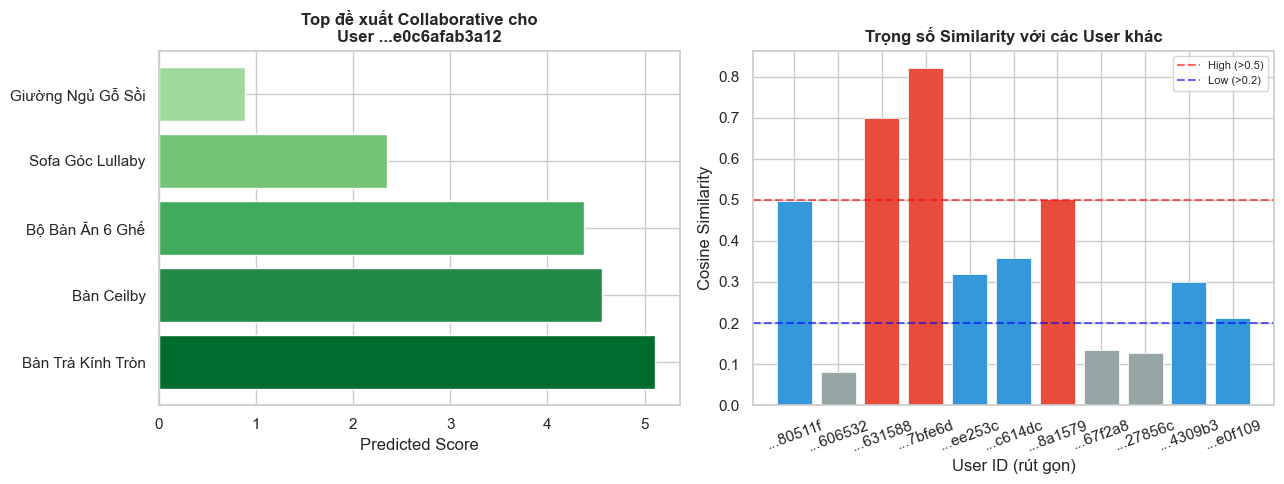

In [15]:
# Visualise kết quả
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Chart 1: Recommended products score
if not recs_df.empty and 'name' in recs_df.columns and 'score' in recs_df.columns:
    n     = len(recs_df)
    # Tạo danh sách màu xanh lá từ nhạt → đậm
    greens = sns.color_palette('Greens', n + 2)[2:]  # bỏ 2 màu đầu quá nhạt
    axes[0].barh(
        recs_df['name'].str[:28],
        recs_df['score'],
        color=list(reversed(greens))
    )
    axes[0].set_title(f'Top đề xuất Collaborative cho\nUser ...{str(target_user)[-12:]}',
                      fontweight='bold')
    axes[0].set_xlabel('Predicted Score')
else:
    axes[0].text(0.5, 0.5, 'Không có đề xuất', ha='center', va='center', fontsize=12)
    axes[0].set_title('Top đề xuất Collaborative', fontweight='bold')

# Chart 2: Weights (similarity với target user)
weights   = sim_df.loc[target_user].drop(target_user)
short_ids = [f'...{str(i)[-6:]}' for i in weights.index]
bar_colors = [
    '#e74c3c' if w > 0.5 else '#3498db' if w > 0.2 else '#95a5a6'
    for w in weights.values
]
axes[1].bar(short_ids, weights.values, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=0.5, color='red',  linestyle='--', alpha=0.6, label='High (>0.5)')
axes[1].axhline(y=0.2, color='blue', linestyle='--', alpha=0.6, label='Low (>0.2)')
axes[1].set_title('Trọng số Similarity với các User khác', fontweight='bold')
axes[1].set_ylabel('Cosine Similarity')
axes[1].set_xlabel('User ID (rút gọn)')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 7. Chạy đề xuất cho tất cả Users

In [18]:
# Đề xuất cho từng user trong hệ thống
print('Kết quả đề xuất cho tất cả users (top-5):')
print('=' * 65)

for uid in matrix.index:
    recs_i = collaborative_recommend(str(uid), top_k=5)
    seen_count = int((matrix.loc[uid] > 0).sum())
    print(f'\nUser ID: {str(uid)} (đã tương tác {seen_count} SP):')
    if recs_i:
        for r in recs_i:
            print(f"   • {r['name'][:35]:<37} score={r['score']:.4f}")
    else:
        print('   (Không có đề xuất)')

Kết quả đề xuất cho tất cả users (top-5):

User ID: 234be2061face0c6afab3a12 (đã tương tác 6 SP):
   • Bàn Trà Kính Tròn                     score=5.1080
   • Bàn Ceilby                            score=4.5671
   • Bộ Bàn Ăn 6 Ghế                       score=4.3770
   • Sofa Góc Lullaby                      score=2.3459
   • Giường Ngủ Gỗ Sồi                     score=0.8913

User ID: 2a7c342dfa799c979a80511f (đã tương tác 4 SP):
   • Bàn Gỗ Điểm Nhấn                      score=6.7969
   • Ghế Điểm Nhấn Larbell                 score=6.1506
   • Bàn Trà Kính Tròn                     score=4.3992
   • Sofa Góc Lullaby                      score=3.5187
   • Bộ Bàn Ăn 6 Ghế                       score=3.0059

User ID: 50d83bf3615543cb3a606532 (đã tương tác 5 SP):
   • Sofa Giường Thông Minh                score=7.0109
   • Sofa Góc Lullaby                      score=4.4353
   • Bàn Gỗ Điểm Nhấn                      score=4.4122
   • Ghế Điểm Nhấn Larbell                 score=2.3895
   • G

## 8. Phân tích mức độ tương đồng giữa users

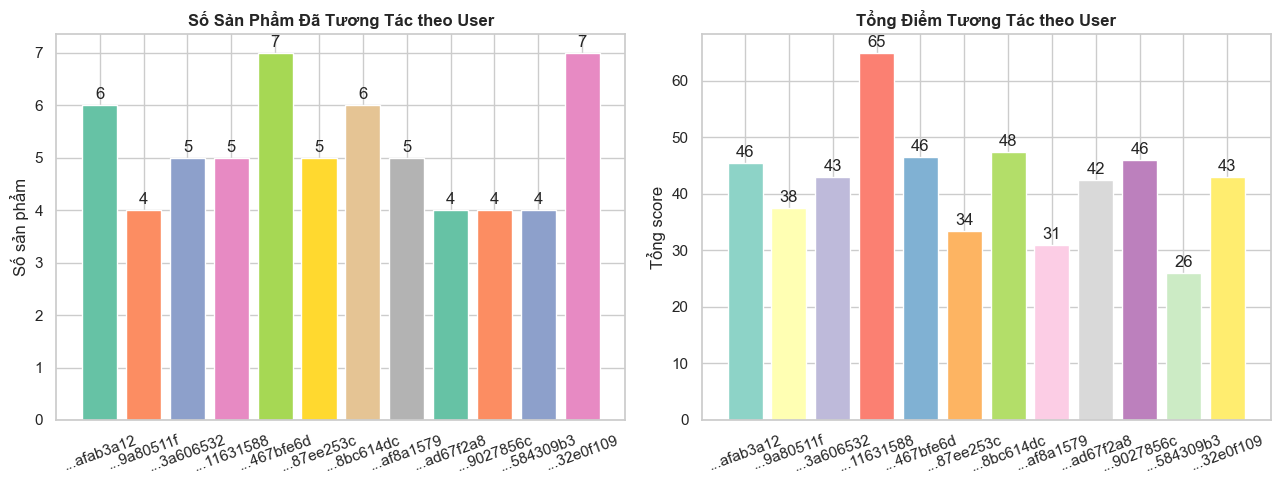

,user_id,n_products,total_score,avg_score
0,...afab3a12,6,45.5,7.583333
1,...9a80511f,4,37.5,9.375000
2,...3a606532,5,43.0,8.600000
3,...11631588,5,65.0,13.000000
4,...467bfe6d,7,46.5,6.642857
5,...87ee253c,5,33.5,6.700000
6,...8bc614dc,6,47.5,7.916667
7,...af8a1579,5,31.0,6.200000
8,...ad67f2a8,4,42.5,10.625000
9,...9027856c,4,46.0,11.500000


In [21]:
# So sánh hành vi tổng hợp của tất cả users
user_stats = []
for uid in matrix.index:
    row = matrix.loc[uid]
    user_stats.append({
        'user_id'    : f'...{str(uid)[-8:]}',
        'n_products' : int((row > 0).sum()),
        'total_score': float(row.sum()),
        'avg_score'  : float(row[row > 0].mean()) if (row > 0).any() else 0.0,
    })

user_stats_df = pd.DataFrame(user_stats)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette1 = sns.color_palette('Set2', len(user_stats_df))
bars = axes[0].bar(user_stats_df['user_id'], user_stats_df['n_products'], color=palette1)
axes[0].bar_label(bars, padding=2)
axes[0].set_title('Số Sản Phẩm Đã Tương Tác theo User', fontweight='bold')
axes[0].set_ylabel('Số sản phẩm')
axes[0].tick_params(axis='x', rotation=20)

palette2 = sns.color_palette('Set3', len(user_stats_df))
bars2 = axes[1].bar(user_stats_df['user_id'], user_stats_df['total_score'], color=palette2)
axes[1].bar_label(bars2, fmt='%.0f', padding=2)
axes[1].set_title('Tổng Điểm Tương Tác theo User', fontweight='bold')
axes[1].set_ylabel('Tổng score')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()
user_stats_df

## 9. Predicted Score heatmap – tất cả users × products chưa tương tác

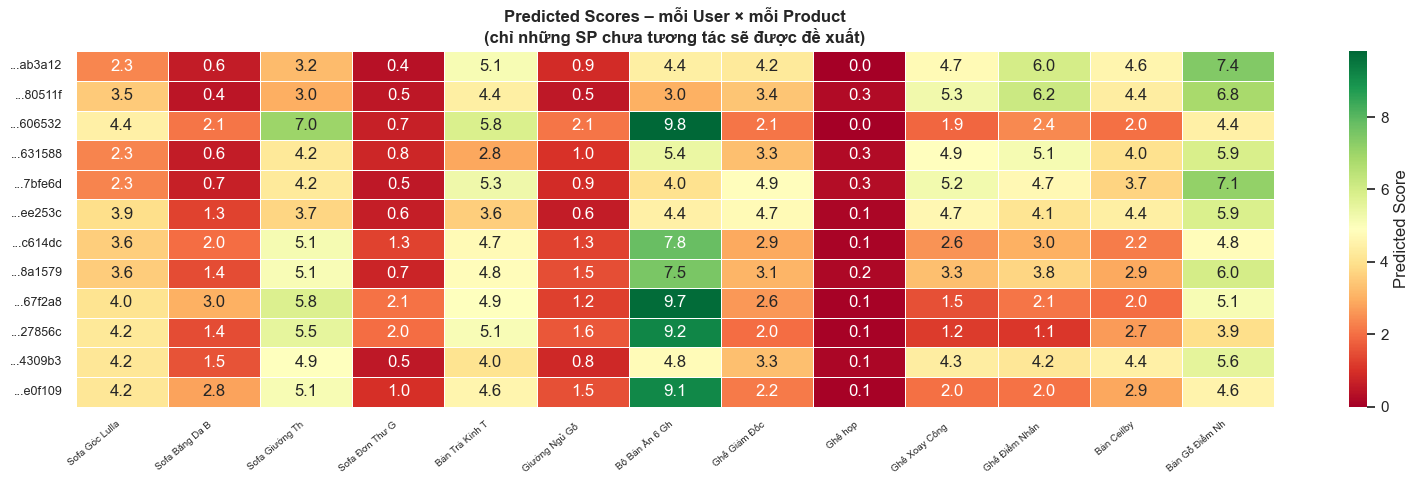

In [22]:
# Tính pred score cho mỗi user × mỗi product (bao gồm cả đã thấy)
pred_rows = {}
for uid in matrix.index:
    weights_i = sim_df.loc[uid].drop(uid)
    if weights_i.abs().sum() == 0:
        pred_rows[str(uid)] = np.zeros(len(matrix.columns))
        continue
    w = np.dot(weights_i.values, matrix.loc[weights_i.index].values)
    pred_rows[str(uid)] = w / (np.abs(weights_i.values).sum() + 1e-8)

pred_df = pd.DataFrame(pred_rows, index=matrix.columns).T

# Rút gọn tên
pred_display         = pred_df.copy()
pred_display.columns = [product_names.get(str(c), str(c))[:14] for c in pred_display.columns]
pred_display.index   = [f'...{str(i)[-6:]}' for i in pred_display.index]

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pred_display, annot=True, fmt='.1f', cmap='RdYlGn',
            ax=ax, linewidths=0.4, cbar_kws={'label': 'Predicted Score'})
ax.set_title('Predicted Scores – mỗi User × mỗi Product\n(chỉ những SP chưa tương tác sẽ được đề xuất)', fontsize=12, fontweight='bold')
plt.xticks(rotation=40, ha='right', fontsize=7)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 9. Tóm tắt luồng xử lý

In [23]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║         Collaborative Filtering – Luồng Xử Lý                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INPUT: reviews[] + orders[]  →  interactions_to_df()         ║
║      score = rating(review) + quantity × 1.5(order)              ║
║                                                                  ║
║  2. pivot_table(user_id, product_id, score, fill_value=0)        ║
║     → User-Item Matrix [U × P]                                   ║
║                                                                  ║
║  3. cosine_similarity(matrix) → User-User Sim [U × U]            ║
║                                                                  ║
║  4. weights = sim_df.loc[target].drop(target)                    ║
║     if weights.abs().sum() == 0 → FALLBACK                       ║
║                                                                  ║
║  5. weighted = dot(weights, matrix[other_users])                 ║
║     pred = weighted / (sum(|weights|) + 1e-8)                   ║
║                                                                  ║
║  6. argsort(pred)[::-1] → bỏ qua seen → top_k                  ║
║                                                                  ║
║  7. Fallback: sum(score) per product (popularity)                ║
║                                                                  ║
║  8. OUTPUT: [{product_id, name, score}, ...]                     ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║         Collaborative Filtering – Luồng Xử Lý                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. INPUT: reviews[] + orders[]  →  interactions_to_df()         ║
║      score = rating(review) + quantity × 1.5(order)              ║
║                                                                  ║
║  2. pivot_table(user_id, product_id, score, fill_value=0)        ║
║     → User-Item Matrix [U × P]                                   ║
║                                                                  ║
║  3. cosine_similarity(matrix) → User-User Sim [U × U]            ║
║                                                                  ║
║  4. weights = sim_df.loc[target].drop(target)                    ║
║     if weights.abs().sum() == 0 → FALLBACK                       ║
║                                 